In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath
import cartopy.crs as ccrs
plt.rcParams['figure.dpi'] = 110

DATA    = Path.home()/'DataFiles'
AWS_MAT = Path.home()/'Downloads'/'Mathieu'/'Data'/'dataAWS.mat'
TAS  = DATA/'tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc'
SMB  = DATA/'smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc'
MASK = DATA/'ANT11_masks.nc'

# Station error variance (K^2). Small but NONZERO: with only 47 annual members
# there are 46 degrees of freedom, and R=0 lets 17 observations collapse the
# ensemble on arithmetic alone (17 random sites then "constrain" 95%).
R_AWS = 0.05

# Ice-core R = k/A, k estimated from 42 replicate core pairs (see the
# OptimalSensorIceTop notebook): sigma^2 = 2.202 per mil^2 at A = 88.2 mm/yr.
D18O_TO_T   = 2.0
SIGMA2_D18O = 2.202
A_CALIB     = 88.2

MIN_SEP_KM = 200.0     # minimum separation between selected sites (11 km grid!)

for p in (TAS, SMB, MASK, AWS_MAT):
    print(('OK      ' if p.exists() else 'MISSING '), p.name)


OK       tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc
OK       smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc
OK       ANT11_masks.nc
OK       dataAWS.mat


In [3]:
mk = xr.open_dataset(MASK)
ice   = mk['Icesheet_Only'].values > 0.5
area  = mk['Area'].values
LAT2D = mk['lat'].values
LON2D = mk['lon'].values
topo  = mk['Topography'].values

def annual(path, var, how='mean'):
    """Annual mean (or sum) from monthly RACMO, read one year at a time.

    Deliberately avoids `chunks=` / dask: peak memory is ~20 MB per year
    rather than a 968 MB load, and it works in environments without dask.
    """
    ds = xr.open_dataset(path)
    da = ds[var]
    if 'height' in da.dims:
        da = da.squeeze('height', drop=True)
    yr = pd.to_datetime(da['time'].values).year.values
    uy = np.unique(yr)
    out = np.empty((uy.size,) + da.shape[1:], dtype='float32')
    for i, y in enumerate(uy):
        s = np.flatnonzero(yr == y)
        blk = da.isel(time=slice(int(s[0]), int(s[-1]) + 1)).values
        out[i] = blk.mean(0) if how == 'mean' else blk.sum(0)
    ds.close()
    return uy.astype(int), out

years, tas = annual(TAS, 'tas')
_,     smb = annual(SMB, 'smbgl', how='sum')

Ye    = tas[:, ice].T.astype(float)                     # (nsite, nyear)
accum = np.clip(smb[:, ice].mean(0).astype(float), 1.0, None)
wts   = area[ice] / area[ice].sum()
J     = (tas[:, ice] * wts).sum(1).astype(float)        # area-weighted mean T

site_lat  = LAT2D[ice]
site_lon  = np.mod(LON2D[ice], 360.0)
site_elev = topo[ice]

NS, nM = Ye.shape
unbias = 1/(nM - 1)
J0var  = unbias * ((J - J.mean())**2).sum()
print(f'{NS:,} ice-sheet cells | {nM} annual members ({years[0]}-{years[-1]}) '
      f'-> {nM-1} DOF')
print(f'metric: area-weighted ice-sheet mean T, variance {J0var:.5f} K^2, '
      f'sd {J.std(ddof=1):.3f} K')
print(f'accumulation: median {np.median(accum):.1f} mm w.e./yr')


113,482 ice-sheet cells | 47 annual members (1979-2025) -> 46 DOF
metric: area-weighted ice-sheet mean T, variance 0.26248 K^2, sd 0.512 K
accumulation: median 86.7 mm w.e./yr


In [4]:
TINY = 1e-12

def variance_reduction(Jdev, Ydev, Rvar, unb):
    den = unb * (Ydev**2).sum(1) + Rvar
    num = (unb * (Ydev @ Jdev))**2
    return np.where(den > TINY, num / np.where(den > TINY, den, 1.0), 0.0)

def adjusted_gain(Kn, Kd, Rb):
    ks = np.sqrt(Kd)
    return Kn / ks / (ks + np.sqrt(Rb))

def haversine_km(la1, lo1, la2, lo2, Rk=6371.0088):
    la1, lo1, la2, lo2 = map(np.radians, (la1, lo1, la2, lo2))
    a = np.sin((la2-la1)/2)**2 + np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 2*Rk*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

class OptimalSensor:
    """DASH @optimalSensor (Comboul et al. 2015), on the RACMO grid."""
    def __init__(self, J, Ye, R):
        J = np.asarray(J, float).ravel()
        self.nM = J.size; self.unbias = 1/(self.nM - 1)
        self.Jdev = J - J.mean()
        Ye = np.asarray(Ye, float)
        self.Ydev = Ye - Ye.mean(1, keepdims=True)
        self.R = (np.full(Ye.shape[0], float(R)) if np.isscalar(R)
                  else np.asarray(R, float).ravel().copy())
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev**2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, i, Rval=None):
        Yb = self.Ydev[i].copy()
        Rb = self.R[i] if Rval is None else Rval
        Yv = self.unbias * (Yb**2).sum()
        if Yv + Rb <= TINY:
            self.Ydev[i] = np.nan
            return self.metric_variance()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Yb), Yv + Rb, Rb)
        self.Jdev = self.Jdev - Ka*Yb
        self.Ydev = self.Ydev - Ka*Yb
        self.Ydev[i] = np.nan
        return self.metric_variance()

    def run(self, N, min_sep_km=0.0, verbose=True):
        """`min_sep_km` matters here -- the grid is 11 km, so without it the
        top-N collapses onto a handful of physical locations."""
        sites, vs = [], []
        banned = np.zeros(self.Ydev.shape[0], bool)
        for s_ in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf)
            dv[banned] = -np.inf
            for k in sites:
                dv[k] = -np.inf
            b = int(np.argmax(dv)); v = self.assimilate(b)
            if min_sep_km > 0:
                banned |= haversine_km(site_lat[b], site_lon[b],
                                       site_lat, site_lon) < min_sep_km
            sites.append(b); vs.append(v)
            if verbose:
                print(f'  {s_+1:3d} site {b:6d} ({site_lat[b]:7.2f}, {site_lon[b]:7.2f})  '
                      f'cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(sites), np.array(vs)

print('OptimalSensor defined')


OptimalSensor defined


In [5]:
_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
rows = []
for n_ in _aws._fieldnames:
    r = getattr(_aws, n_)
    la, lo = float(r.lat), np.mod(float(r.lon), 360.0)
    d = haversine_km(la, lo, site_lat, site_lon); k = int(np.argmin(d))
    rows.append(dict(station=n_, lat=la, lon=lo, site=k, km=d[k],
                     accum=accum[k], elev=site_elev[k]))
aws_map = pd.DataFrame(rows)
AWS_SITES = sorted(set(aws_map.site))
print(f'{len(aws_map)} stations -> {len(AWS_SITES)} cells, '
      f'max offset {aws_map.km.max():.0f} km')
print(f'station elevation: median {aws_map.elev.median():.0f} m  '
      f'vs ice-sheet median {np.median(site_elev):.0f} m')
aws_map.round(1)


17 stations -> 17 cells, max offset 143 km
station elevation: median 209 m  vs ice-sheet median 2146 m


,station,lat,lon,site,km,accum,elev
0,FaradayVernadsky,-65.1,295.8,63094,10.5,2750.6,351.500000
1,Rothera,-67.3,291.9,54247,11.3,2933.3,854.099976
2,Byrd,-80.0,240.7,19215,6.0,113.9,1545.099976
3,Marambio,-64.2,303.4,75464,75.8,767.2,208.500000
4,Mawson,-67.6,62.9,105504,11.2,1.0,374.200012
5,Davis,-68.6,78.0,92320,4.6,167.0,12.100000
6,McMurdo,-77.9,166.7,9867,6.9,177.9,14.700000
7,DDU,-66.7,140.0,6806,9.3,271.7,222.600006
8,Bellingshausen,-62.1,301.4,74424,142.9,1634.9,178.500000
9,Neumayer,-70.4,351.8,107229,19.0,291.8,14.200000


In [6]:
K_TEMP = D18O_TO_T**2 * SIGMA2_D18O * A_CALIB
R_ICE_CORE = K_TEMP / accum
print(f'k_temp = {K_TEMP:.0f}  ->  R = k/A')
print(f'  median {np.median(R_ICE_CORE):.2f} K^2, '
      f'range {R_ICE_CORE.min():.3f} .. {R_ICE_CORE.max():.0f}')
print(f'  site Ye variance median {np.median(unbias*((Ye-Ye.mean(1,keepdims=True))**2).sum(1)):.3f} K^2')


k_temp = 777  ->  R = k/A
  median 8.96 K^2, range 0.138 .. 777
  site Ye variance median 0.701 K^2


In [7]:
rng = np.random.default_rng(0)

def constrain(idx, Rval):
    o = OptimalSensor(J, Ye, 0.0)
    for i in idx:
        o.assimilate(int(i), Rval=Rval)
    return 100 * (1 - o.metric_variance()/o.J0var)

real = constrain(AWS_SITES, R_AWS)
rand = [constrain(rng.choice(NS, len(AWS_SITES), replace=False), R_AWS)
        for _ in range(20)]
print(f'DOF budget: {len(AWS_SITES)} obs / {nM-1} DOF = '
      f'{100*len(AWS_SITES)/(nM-1):.0f}%')
print(f'AWS network (R={R_AWS}) constrains  {real:.1f}%')
print(f'{len(AWS_SITES)} RANDOM sites constrain      '
      f'{np.mean(rand):.1f}% +/- {np.std(rand):.1f}%')
print(f'  real - random = {real-np.mean(rand):+.1f}%')
print('  -> with 46 DOF the absolute % is inflated; read it against the '
      'random baseline.')


DOF budget: 17 obs / 46 DOF = 37%
AWS network (R=0.05) constrains  92.8%
17 RANDOM sites constrain      94.3% +/- 1.2%
  real - random = -1.5%
  -> with 46 DOF the absolute % is inflated; read it against the random baseline.


In [8]:
def experiment(candidate_R, n_top=10, min_sep_km=MIN_SEP_KM):
    o = OptimalSensor(J, Ye, candidate_R)
    J0 = o.J0var
    for i in AWS_SITES:
        o.assimilate(int(i), Rval=R_AWS)      # existing network, small R
    v0 = o.metric_variance()
    dv = o.evaluate()
    st, vr = o.run(n_top, min_sep_km=min_sep_km, verbose=False)
    return J0, v0, np.where(np.isfinite(dv), dv, np.nan), st, vr

res = {}
for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS)]:
    res[lbl] = experiment(cand)
    J0, v0, dv, st, vr = res[lbl]
    print(f'\n=== new {lbl} ===   AWS network leaves {v0:.5f} of {J0:.5f}')
    print(pd.DataFrame({
        'rank': range(1, 11), 'site': st,
        'lat': site_lat[st], 'lon': site_lon[st],
        'elev': site_elev[st], 'accum': accum[st],
        'R': (R_ICE_CORE[st] if lbl == 'ICE CORE' else np.full(10, R_AWS)),
        'pct_remaining': 100*(1 - vr/v0),
    }).set_index('rank').round(2).to_string())



=== new ICE CORE ===   AWS network leaves 0.01900 of 0.26248
        site    lat     lon         elev    accum     R  pct_remaining
rank                                                                  
1       7425 -74.16  246.13   445.209991  1876.23  0.41           4.58
2     110819 -67.30   54.82  1175.459961   900.03  0.86           8.19
3     112845 -69.64   34.59   606.799988  1688.65  0.46          10.44
4      39180 -75.68  279.63   662.330017   610.46  1.27          12.10
5      23758 -66.46  127.22    13.300000  1345.67  0.58          13.76
6      70151 -67.85   98.68  1512.790039   672.96  1.15          15.49
7       2675 -77.13  205.99    22.580000   880.78  0.88          16.76
8     112882 -67.86   47.03   924.849976   974.26  0.80          17.96
9      32075 -66.59  121.90    14.370000   627.88  1.24          19.10
10     16003 -69.20  135.13  2427.699951   228.34  3.40          20.30

=== new AWS ===   AWS network leaves 0.01900 of 0.26248
        site    lat     lon  

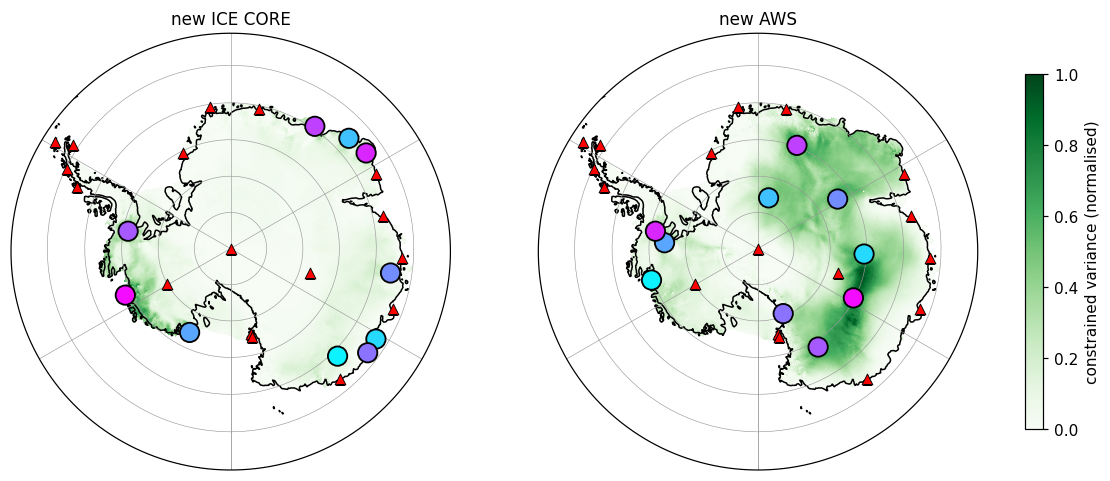

In [9]:
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()

def plot_native(vals, title, top_idx=None, ax=None, fig=None):
    """Plot on the native 11 km RACMO grid -- no interpolation needed."""
    grid = np.full(ice.shape, np.nan); grid[ice] = vals
    if ax is None:
        fig = plt.figure(figsize=(9, 9)); ax = plt.axes(projection=SP)
    ax.set_extent([-180, 180, -90, -60], PL)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                    transform=ax.transAxes)
    ax.gridlines(linewidth=.4, color='0.6')
    pm = ax.pcolormesh(LON2D, LAT2D, grid, transform=PL, cmap=plt.cm.Greens,
                       vmin=0, vmax=1, shading='auto')
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=50, c='red',
               edgecolors='k', lw=.6, transform=PL, zorder=3)
    if top_idx is not None:
        n = len(top_idx); rk = np.arange(1, n+1); o = np.arange(n)[::-1]
        ax.scatter(site_lon[top_idx][o], site_lat[top_idx][o], c=rk[o], s=160,
                   lw=1.2, edgecolors='k', cmap=plt.cm.cool_r,
                   vmin=.5, vmax=n+.5, transform=PL, zorder=4)
    ax.coastlines(); ax.set_title(title, fontsize=11)
    return fig, ax, pm

fig = plt.figure(figsize=(14, 7))
for i, (lbl, (J0, v0, dv, st, vr)) in enumerate(res.items()):
    ax = fig.add_subplot(1, 2, i+1, projection=SP)
    _, _, pm = plot_native(dv/np.nanmax(dv), f'new {lbl}', top_idx=st, ax=ax, fig=fig)
cb = fig.colorbar(pm, ax=fig.axes, shrink=.6, pad=.04)
cb.set_label('constrained variance (normalised)')
plt.show()


In [10]:
# IMBIE basins from ANT11_masks.nc, grouped by centroid geography.
# Grounded-only areas: EAIS 10.13, WAIS 1.88, AP 0.31 M km^2 -- matching
# published values (10.2 / 1.97 / 0.23-0.4).
mk = xr.open_dataset(MASK)
site_area    = mk['Area'].values[ice]
site_basin   = mk['Basins'].values[ice]
site_grounded = np.load(DATA/'ANT11_grounded_mask.npy')[ice]

REGIONS = {
    'EAIS': [2, 4, 5, 7, 9, 12, 13, 14, 15, 17],
    'WAIS': [1, 18, 20, 21, 23],     # incl. basin 1, the Ronne/Filchner catchment
    'AP':   [24, 25, 27],
}
region_mask = {k: (np.isin(site_basin, v) & site_grounded)
               for k, v in REGIONS.items()}

for k, v in region_mask.items():
    print(f'{k:5s} {v.sum():7,d} grounded cells   {site_area[v].sum()/1e6:5.2f} M km2')
unassigned = site_grounded & ~np.isin(site_basin, sum(REGIONS.values(), []))
print(f'unassigned grounded cells: {unassigned.sum()}')


EAIS   82,922 grounded cells   10.13 M km2
WAIS   15,554 grounded cells    1.88 M km2
AP      2,545 grounded cells    0.31 M km2
unassigned grounded cells: 1


In [11]:
def build_metric(mask):
    """Area-weighted mean temperature over `mask`, using RACMO's own cell areas."""
    w = site_area[mask]
    return (Ye[mask] * w[:, None]).sum(0) / w.sum()

metrics = {}
for rn, rm in region_mask.items():
    Jr = build_metric(rm)
    metrics[rn] = Jr
    print(f'{rn:5s} mean {Jr.mean():7.2f} K   sd {Jr.std(ddof=1):.3f} K   '
          f'variance {unbias*((Jr-Jr.mean())**2).sum():.5f}')


EAIS  mean  233.89 K   sd 0.599 K   variance 0.35897
WAIS  mean  247.39 K   sd 0.683 K   variance 0.46663
AP    mean  258.25 K   sd 0.783 K   variance 0.61298


In [12]:
def experiment_for(J, candidate_R):
    """Pre-assimilate the AWS network at R_AWS, then evaluate every site."""
    o = OptimalSensor(J, Ye, candidate_R)
    J0 = o.J0var
    for i in AWS_SITES:
        o.assimilate(int(i), Rval=R_AWS)
    dv = o.evaluate()
    return J0, o.metric_variance(), np.where(np.isfinite(dv), dv, np.nan)

R_ICE_CORE = K_TEMP / np.clip(accum, 1.0, None)

reg_res = {}
for rn in REGIONS:
    for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS)]:
        J0, v0, dv = experiment_for(metrics[rn], cand)
        reg_res[(rn, lbl)] = (J0, v0, dv)
        k = int(np.nanargmax(dv))
        print(f'{rn:5s} {lbl:9s}  AWS net {100*(1-v0/J0):5.1f}%  |  '
              f'best site {k:6d} ({site_lat[k]:7.2f}, {site_lon[k]:7.2f})  '
              f'accum {accum[k]:7.1f}  ->  +{100*np.nanmax(dv)/v0:5.2f}% of remaining')


EAIS  ICE CORE   AWS net  92.8%  |  best site  64556 ( -72.42,  300.23)  accum   316.6  ->  + 4.43% of remaining
EAIS  AWS        AWS net  92.8%  |  best site 100942 ( -75.26,   27.78)  accum    44.5  ->  +37.68% of remaining
WAIS  ICE CORE   AWS net  90.4%  |  best site  12398 ( -75.35,  249.79)  accum  2382.2  ->  +21.97% of remaining
WAIS  AWS        AWS net  90.4%  |  best site  35678 ( -80.75,  268.63)  accum   139.0  ->  +52.96% of remaining
AP    ICE CORE   AWS net  91.9%  |  best site  18333 ( -71.89,  263.74)  accum  1790.9  ->  +22.87% of remaining
AP    AWS        AWS net  91.9%  |  best site  60806 ( -72.85,  297.76)  accum   320.5  ->  +60.39% of remaining


NameError: name 'matplotlib' is not defined

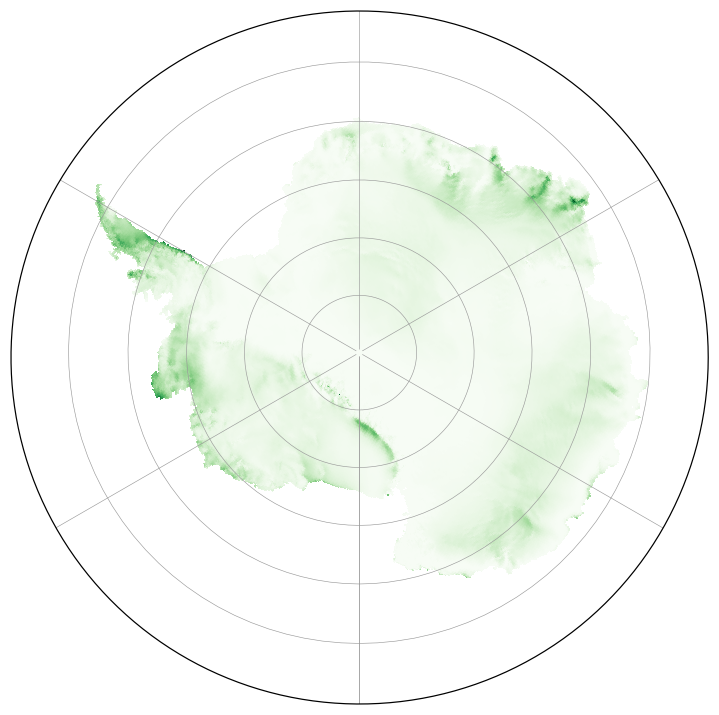

In [ ]:
def edge_cells(mask2d):
    """Cells on the boundary of a mask, by 4-neighbour comparison.

    Used instead of ax.contour(): contouring a 0/1 field on the rotated-pole
    lon/lat grid draws spurious lines around isolated islands (Berkner,
    Roosevelt) and across the pole where longitudes converge -- that was the
    'spits' into the Weddell and Ross seas and the hexagon at the South Pole.
    """
    er = np.zeros_like(mask2d)
    for sh, ax_ in ((1, 0), (-1, 0), (1, 1), (-1, 1)):
        er |= mask2d & ~np.roll(mask2d, sh, axis=ax_)
    return er

# region masks back on the 2-D grid, for outlining
region_2d = {}
for rn, ids in REGIONS.items():
    r2 = np.zeros(ice.shape, bool)
    r2[ice] = region_mask[rn]
    region_2d[rn] = r2

SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 21))

for r, rn in enumerate(REGIONS):
    for c, lbl in enumerate(['ICE CORE', 'AWS']):
        J0, v0, dv = reg_res[(rn, lbl)]
        ax = fig.add_axes([0.02 + c*0.47, 0.68 - r*0.325, 0.44, 0.30],
                          projection=SP)
        ax.set_extent([-180, 180, -90, -60], PL)
        th = np.linspace(0, 2*np.pi, 200)
        ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                        transform=ax.transAxes)
        ax.gridlines(linewidth=.4, color='0.6')

        grid = np.full(ice.shape, np.nan); grid[ice] = dv/np.nanmax(dv)
        pm = ax.pcolormesh(LON2D, LAT2D, grid, transform=PL, cmap=plt.cm.Greens,
                           vmin=0, vmax=1, shading='auto')

        # region outline drawn as boundary CELLS, not a contour
        ed = np.where(edge_cells(region_2d[rn]), 1.0, np.nan)
        ax.pcolormesh(LON2D, LAT2D, ed, transform=PL,
                      cmap=matplotlib.colors.ListedColormap(['navy']),
                      vmin=0, vmax=1, shading='auto', zorder=2)

        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=45, c='red',
                   edgecolors='k', lw=.5, transform=PL, zorder=3)
        ax.coastlines()
        ax.set_title(f'{rn} metric — new {lbl}', fontsize=13)

cax = fig.add_axes([0.93, 0.25, 0.017, 0.5])
cb = fig.colorbar(pm, cax=cax)
cb.set_label('constrained variance (normalised)', fontsize=12)
plt.show()
